## makemore: part 5

https://arxiv.org/pdf/1609.03499

In [ ]:
a = torch.randn((2, 1, 2))
a.squeeze(1).shape

torch.Size([2, 2])

Run the following analysis.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

Display the output.

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt

# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

--2024-09-24 15:04:38--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt.3’

names.txt.3         100%[===================>] 222.80K  --.-KB/s    in 0.003s  

2024-09-24 15:04:38 (63.9 MB/s) - ‘names.txt.3’ saved [228145/228145]

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


Display the output.

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


Run the following analysis.

In [ ]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

Display the output.

In [ ]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []

  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


Display the output.

In [ ]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


Evaluate the model on the test set.

In [ ]:
# Near copy paste of the layers we have developed in Part 3

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
# TODO: use previous batch norm first, then fix it after first training run
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))

  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out

  def parameters(self):
    return [self.weight]

# TODO: use original flatten first
# -----------------------------------------------------------------------------------------------
class FlattenConsecutive: # named Flatten different because its different from python api

  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]


Run the following analysis.

In [ ]:
torch.manual_seed(42); # seed rng for reproducibility

Evaluate the model on the test set.

In [ ]:
# original network
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(8), Linear(n_embd * 8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# hierarchical network
#n_embd = 24 # the dimensionality of the character embedding vectors
#n_hidden = 128 # the number of neurons in the hidden layer of the MLP
#model = Sequential([
#  Embedding(vocab_size, n_embd),
#  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
#  Linear(n_hidden, vocab_size),
#])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22097


Display training results and metrics.

In [ ]:
# same optimization as last time
max_steps = 1000#200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update: simple SGD
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/   1000: 3.2847


Visualize the results.

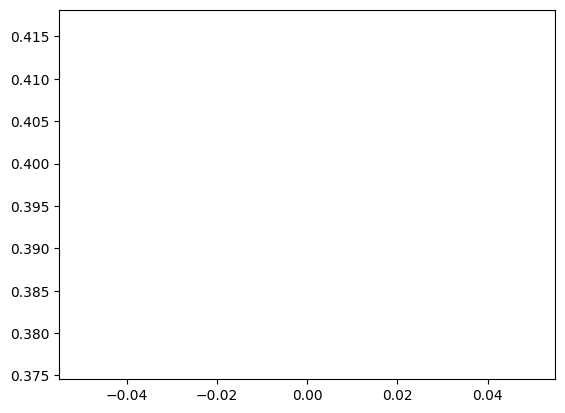

In [ ]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

Run the following analysis.

In [ ]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
  layer.training = False

Display training results and metrics.

In [ ]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.384119749069214
val 2.3817715644836426


### performance log

- original (3 character context + 200 hidden neurons, 12K params): train 2.058, val 2.105
- context: 3 -> 8 (22K params): train 1.918, val 2.027
- flat -> hierarchical (22K params): train 1.941, val 2.029
- fix bug in batchnorm: train 1.912, val 2.022
- scale up the network: n_embd 24, n_hidden 128 (76K params): train 1.769, val 1.993


In [ ]:
# sample from the model
for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

covyan.
berl.
uviti.
befeyxt.
antra.
cablitla.
wafori.
aqann.
eemaun.
leri.
cuile.
eed.
olhi.
kyie.
jhalir.
jexia.
erigs.
viatani.
lonaisr.
auryahan.


Run the following analysis.

In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4,))
ix.shape, ix

(torch.Size([4]), tensor([74314, 16418, 55433, 88326]))

Run the following analysis.

In [ ]:
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb.shape, Xb

(torch.Size([4, 8]),
 tensor([[ 0,  0,  0,  0,  0,  0,  0,  0],
         [11,  1, 20,  8,  5, 18,  9, 14],
         [ 0,  0,  0,  0,  0,  0,  0,  0],
         [ 0,  0,  0,  0,  0,  0,  0,  0]]))

Execute a quick computation.

In [ ]:
model.layers[0].out.shape # output of embedding

torch.Size([4, 8, 10])

Execute a quick computation.

In [ ]:
model.layers[1].out.shape # output of flatten

torch.Size([4, 80])

Execute a quick computation.

In [ ]:
model.layers[2].out.shape # output of linear

torch.Size([4, 200])

Run the following analysis.

In [ ]:
(torch.randn((4, 80)) @ torch.randn((80, 200)) + torch.randn(200)).shape

torch.Size([4, 200])

Run the following analysis.

In [ ]:
(torch.randn((4, 5, 2, 80)) @ torch.randn((80, 200)) + torch.randn(200)).shape # only last dimension is used and the others are unchanged

torch.Size([4, 5, 2, 200])

Execute a quick computation.

In [ ]:
# (1 2) (3 4) (5 6) (7 8)

Run the following analysis.

In [ ]:
(torch.randn((4, 4, 20)) @ torch.randn((20, 200)) + torch.randn(200)).shape

Execute a quick computation.

In [ ]:
e = torch.randn(4, 8, 10)
e.view(4, -1).shape

torch.Size([4, 8, 10])

Run the following analysis.

In [ ]:
(
    list(range(10))[0::2], # Even numbers
    list(range(10))[1::2]  # Odd numbers
)

([0, 2, 4, 6, 8], [1, 3, 5, 7, 9])

Run the following analysis.

In [ ]:
e = torch.randn(4, 8, 10)
evenchars = e[:, 0::2, :]
oddchars = e[:, 1::2, :]
evenchars.shape, oddchars.shape

(torch.Size([4, 4, 10]), torch.Size([4, 4, 10]))

Execute a quick computation.

In [ ]:
torch.cat([evenchars, oddchars], dim=2).shape

torch.Size([4, 4, 20])

Run the following analysis.

In [ ]:
(e.view(4, 4, 20) == torch.cat([evenchars, oddchars], dim=2)).all()

tensor(True)

Display the output.

In [ ]:
for layer in model.layers:
  layer_name = layer.__class__.__name__
  print(f"{layer_name}:", tuple(layer.out.shape))

Embedding: (1, 8, 10)
FlattenConsecutive: (1, 80)
Linear: (1, 200)
BatchNorm1d: (1, 200)
Tanh: (1, 200)
Linear: (1, 27)


Evaluate the model on the test set.

In [ ]:

# hierarchical network
#n_embd = 24 # the dimensionality of the character embedding vectors
#n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

170897


Run the following analysis.

In [ ]:
ix = torch.randint(0, Xtr.shape[0], (4,))
ix.shape, ix
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
Xb.shape, Xb

(torch.Size([4, 8]),
 tensor([[ 0,  0,  0,  0,  0,  8,  1, 18],
         [ 0,  0,  0,  0,  5,  4, 13, 15],
         [ 0,  4,  5, 12,  6,  9, 14,  1],
         [ 0,  0,  0,  0,  5,  4,  5, 18]]))

Display the output.

In [ ]:
for layer in model.layers:
  layer_name = layer.__class__.__name__
  print(f"{layer_name}:", tuple(layer.out.shape))

Embedding: (4, 8, 10)
FlattenConsecutive: (4, 4, 20)
Linear: (4, 4, 200)
BatchNorm1d: (4, 4, 200)
Tanh: (4, 4, 200)
FlattenConsecutive: (4, 2, 400)
Linear: (4, 2, 200)
BatchNorm1d: (4, 2, 200)
Tanh: (4, 2, 200)
FlattenConsecutive: (4, 400)
Linear: (4, 200)
BatchNorm1d: (4, 200)
Tanh: (4, 200)
Linear: (4, 27)


Evaluate the model on the test set.

In [ ]:
# TODO: note set n_hidden 68 so that we get same parameter count as original NN
# hierarchical network
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

22397


Run the following analysis.

In [ ]:
# TODO: train
# TODO: measure loss
# TODO: expect loss to not improve

Run the following analysis.

In [ ]:
# TODO: batch norm is busted
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True) # 1, 4, 68
evar = e.var(0, keepdim=True) # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68

Run the following analysis.

In [ ]:
model.layers[3].running_mean.shape # TODO: bug, expected [1, 4, 68]

torch.Size([68])

Run the following analysis.

In [ ]:
# TODO: batch norm is busted
e = torch.randn(32, 4, 68)
emean = e.mean((0, 1), keepdim=True) # 1, 4, 68
evar = e.var((0, 1), keepdim=True) # 1, 4, 68
ehat = (e - emean) / torch.sqrt(evar + 1e-5) # 32, 4, 68
ehat.shape, emean.shape, evar.shape

(torch.Size([32, 4, 68]), torch.Size([1, 1, 68]), torch.Size([1, 1, 68]))

TODO: we expect (N,C) or (N, L, C), pytorch expects (N,C) or (N, C, L)

https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html

In [ ]:
#TODO: fix batch norm
#TODO: train again
model.layers[3].running_mean.shape # TODO: fixed
#TODO: expect slight improvement in val loss

Evaluate the model on the test set.

In [ ]:
# TODO: note set n_hidden 68 so that we get same parameter count as original NN
# hierarchical network
n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
  model.layers[-1].weight *= 0.1 # last layer make less confident

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

TODO: expect val loss below 2.0 (1.99)

NOTE: we didnt implement residual connections

### Next time:
Why convolutions? Brief preview/hint

In [ ]:
for x,y in zip(Xtr[7:15], Ytr[7:15]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .


Execute a quick computation.

In [ ]:
Xtr[7].shape

torch.Size([8])

Execute a quick computation.

In [ ]:
Xtr[[7]].shape

torch.Size([1, 8])

Run the following analysis.

In [ ]:
# forward a single example:
logits = model(Xtr[[7]])
logits.shape

torch.Size([1, 27])

Run the following analysis.

In [ ]:
# forward all of them
logits = torch.zeros(8, 27)
for i in range(8):
  logits[i] = model(Xtr[[7+i]])
logits.shape

torch.Size([8, 27])

Run the following analysis.

In [ ]:
# convolution is a "for loop"
# allows us to forward Linear layers efficiently over space

# TODO: check if someone did this part (eg: other notebooks)
# TODO: consider adding residual connections